In [1]:
#import zipfile
import os


file_path_A_first = os.getcwd() + "\\Exp-A_HDF5_Run-1.zip"
file_path_B_first = os.getcwd() + "\\Exp-B_HDF5_Run-1.zip"
file_path_C_first = os.getcwd() + "\\Exp-C_HDF5_Run-1.zip"

file_path_A_last = os.getcwd() + "\\Exp-A_HDF5_Run-5.zip"
file_path_B_last = os.getcwd() + "\\Exp-B_HDF5_Run-7.zip"
file_path_C_last = os.getcwd() + "\\Exp-C_HDF5_Run-12.zip"

paths = [
    file_path_A_first, file_path_B_first, file_path_C_first,
    file_path_A_last,  file_path_B_last,  file_path_C_last
]


# sample size of dataset

In [2]:
import zipfile
import h5py
import numpy as np
import io

def extract_features_from_zip(zip_path, hdf5_filename, downsample=10):
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(hdf5_filename) as f:
            file_bytes = f.read()
            file_obj = io.BytesIO(file_bytes)

            with h5py.File(file_obj, 'r') as hdf:

                rms = hdf["CI/rms"][:]
                kurtosis = hdf["CI/kurtosis"][:]
                speed = hdf["Context/PAU Speed"][:]
                torque = hdf["Context/PAU Torque"][:]

                # Downsampling
                rms = rms[::downsample]
                kurtosis = kurtosis[::downsample]
                speed = speed[::downsample]
                torque = torque[::downsample]


                min_len = min(len(rms), len(kurtosis), len(speed), len(torque))

                rms = rms[:min_len]
                kurtosis = kurtosis[:min_len]
                speed = speed[:min_len]
                torque = torque[:min_len]

                features = np.stack([rms, kurtosis, speed, torque], axis=1)
    return features

def find_file_in_zip(zip_path, target_name):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for name in z.namelist():
            if target_name in name:
                return name
    return None






In [3]:

import re
import zipfile
import numpy as np

#keep gears isolated


path_to_gear = {
    file_path_A_first: "gear1",
    file_path_B_first: "gear2",
    file_path_C_first: "gear3",
    
    file_path_A_last: "gear1",
    file_path_B_last: "gear2",
    file_path_C_last: "gear3",
}


path_to_run = {
    file_path_A_first: "first",
    file_path_B_first: "first",
    file_path_C_first: "first",
    file_path_A_last:  "last",
    file_path_B_last:  "last",
    file_path_C_last:  "last",
}


path_to_run_folder = {
    file_path_A_first: "Run-1",
    file_path_B_first: "Run-1",
    file_path_C_first: "Run-1",

    file_path_A_last: "Run-5",
    file_path_B_last: "Run-7",
    file_path_C_last: "Run-12",
}


data = {
    "gear1": {"first": None, "last": None},
    "gear2": {"first": None, "last": None},
    "gear3": {"first": None, "last": None},
}



def select_hdf5_members(zip_path, run_folder, take_last, n):
    import zipfile, re

    with zipfile.ZipFile(zip_path, "r") as z:
        members = [
            m for m in z.namelist()
            if m.endswith(".hdf5") and f"{run_folder}/" in m
        ]

   
    print(f"Using folder: {run_folder}")
    print("Example matches:", members[:3])
    print(f"Total available files in {run_folder}:", len(members))

    def get_index(name):
        m = re.search(r"_(\d+)\.hdf5$", name)
        return int(m.group(1)) if m else -1

    members.sort(key=get_index)
    


    return members[-n:] if take_last else members[:n]



for path in paths:
    gear_key = path_to_gear[path]
    run_label = path_to_run[path]
    run_folder = path_to_run_folder[path]
    

    take_last = (run_label == "last")
    n_files = 20 if take_last else 21

    hdf5_members = select_hdf5_members(
        path,
        run_folder=run_folder,
        take_last=take_last,
        n=n_files
    )

    print(f"{gear_key} {run_label}: selected {len(hdf5_members)} files")
    print("  first:", hdf5_members[0])
    print("  last :", hdf5_members[-1])

    all_features = []
    for member in hdf5_members:
        features = extract_features_from_zip(path, member)
        all_features.append(features)

    sample_dataset = np.concatenate(all_features, axis=0)
    print("  shape:", sample_dataset.shape)

    data[gear_key][run_label] = sample_dataset

for gear in data:
    print(f"\n{gear}")
    print("  first shape:", data[gear]["first"].shape)
    print("  last  shape:", data[gear]["last"].shape)



Using folder: Run-1
Example matches: ['Run-1/Dyno Gear233Run1_00000.hdf5', 'Run-1/Dyno Gear233Run1_00001.hdf5', 'Run-1/Dyno Gear233Run1_00002.hdf5']
Total available files in Run-1: 372
gear1 first: selected 21 files
  first: Run-1/Dyno Gear233Run1_00000.hdf5
  last : Run-1/Dyno Gear233Run1_00010.hdf5
  shape: (121, 4)
Using folder: Run-1
Example matches: ['Run-1/Dyno Gear303Run1_00000.hdf5', 'Run-1/Dyno Gear303Run1_00001.hdf5', 'Run-1/Dyno Gear303Run1_00002.hdf5']
Total available files in Run-1: 372
gear2 first: selected 21 files
  first: Run-1/Dyno Gear303Run1_00000.hdf5
  last : Run-1/Dyno Gear303Run1_00010.hdf5
  shape: (120, 4)
Using folder: Run-1
Example matches: ['Run-1/Dyno Gear303Run1_00000.hdf5', 'Run-1/Dyno Gear303Run1_00001.hdf5', 'Run-1/Dyno Gear303Run1_00002.hdf5']
Total available files in Run-1: 370
gear3 first: selected 21 files
  first: Run-1/Dyno Gear303Run1_00000.hdf5
  last : Run-1/Dyno Gear303Run2_00006.hdf5
  shape: (126, 4)
Using folder: Run-5
Example matches: ['R

## sliding windows

In [4]:
import numpy as np

def make_windows(seq, window_size=20, stride=1):
    T = len(seq)
    if T < window_size:
        return np.empty((0, window_size, seq.shape[1]), dtype=seq.dtype)
    X = []
    for i in range(0, T - window_size + 1, stride):
        X.append(seq[i:i+window_size])
    return np.asarray(X)  # (n_windows, window_size, n_features)

def flatten_windows(X):
    return X.reshape(X.shape[0], -1)  # (n_samples, window_size*n_features)


def window_features_stats(Xw):
    # Xw: (n_samples, window, n_features)
    mean = Xw.mean(axis=1)
    std  = Xw.std(axis=1)
    mn   = Xw.min(axis=1)
    mx   = Xw.max(axis=1)


    t = np.arange(Xw.shape[1])
    t = (t - t.mean()) / (t.std() + 1e-9)
    slope = (Xw * t[None, :, None]).mean(axis=1)

    return np.concatenate([mean, std, mn, mx, slope], axis=1)


## Health Indicator for labels

In [5]:
def window_health_indicators(Xw):
    """
    Xw: (n_windows, window_size, 4) with columns [rms,kurt,speed,torque]
    returns dict of indicator arrays shape (n_windows,)
    """
    rms  = Xw[:, :, 0]
    kurt = Xw[:, :, 1]
    spd  = Xw[:, :, 2]
    trq  = Xw[:, :, 3]

    rms_mean  = rms.mean(axis=1)
    kurt_mean = kurt.mean(axis=1)
    spd_mean  = spd.mean(axis=1)
    trq_mean  = trq.mean(axis=1)

    # slope in window (simple linear trend)
    t = np.arange(Xw.shape[1], dtype=np.float32)
    t = (t - t.mean()) / (t.std() + 1e-9)

    rms_slope  = (rms * t[None, :]).mean(axis=1)
    kurt_slope = (kurt * t[None, :]).mean(axis=1)

    return {
        "rms_mean": rms_mean,
        "kurt_mean": kurt_mean,
        "rms_slope": rms_slope,
        "kurt_slope": kurt_slope,
        "speed_mean": spd_mean,
        "torque_mean": trq_mean
    }

def anchored_health_index(ind_first, ind_last,
                          w=(0.6, 0.4, 0.0, 0.0),
                          use_slopes=True,
                          clip=True,
                          monotonic=True):
    """
    ind_first / ind_last: output dict from window_health_indicators for first/last
    w: weights for (rms_mean, kurt_mean, rms_slope_pos, kurt_slope_pos)
    Anchors:
      low  = percentile(first_score, 5)
      high = percentile(last_score, 95)
    Produces HI in [0,1] for both runs.
    """

    # build raw score
    sF = w[0]*ind_first["rms_mean"] + w[1]*ind_first["kurt_mean"]
    sL = w[0]*ind_last["rms_mean"]  + w[1]*ind_last["kurt_mean"]

    if use_slopes:
        # only positive slopes contribute to damage
        sF = sF + w[2]*np.maximum(ind_first["rms_slope"], 0) + w[3]*np.maximum(ind_first["kurt_slope"], 0)
        sL = sL + w[2]*np.maximum(ind_last["rms_slope"],  0) + w[3]*np.maximum(ind_last["kurt_slope"],  0)

    # robust anchors
    low  = np.percentile(sF, 5)
    high = np.percentile(sL, 95)
    denom = (high - low) + 1e-8

    hiF = (sF - low) / denom
    hiL = (sL - low) / denom

    if clip:
        hiF = np.clip(hiF, 0.0, 1.0)
        hiL = np.clip(hiL, 0.0, 1.0)

    if monotonic:
        hiF = np.maximum.accumulate(hiF)
        hiL = np.maximum.accumulate(hiL)

        # re-clip after accumulate
        if clip:
            hiF = np.clip(hiF, 0.0, 1.0)
            hiL = np.clip(hiL, 0.0, 1.0)

    return hiF.astype(np.float32), hiL.astype(np.float32)

def window_feature_vector(Xw):
    # Xw: (n_windows, win, 4)
    mean = Xw.mean(axis=1)
    std  = Xw.std(axis=1)
    mn   = Xw.min(axis=1)
    mx   = Xw.max(axis=1)

    t = np.arange(Xw.shape[1], dtype=np.float32)
    t = (t - t.mean()) / (t.std() + 1e-9)
    slope = (Xw * t[None, :, None]).mean(axis=1)

    return np.concatenate([mean, std, mn, mx, slope], axis=1)  # (n_windows, 20)

In [6]:
def extract_health_indicators(X_feat):
    # X_feat shape: (n_windows, 20) if 4 features * 5 stats\n",
    rms_mean  = X_feat[:, 0]
    kurt_mean = X_feat[:, 1]
    rms_slope  = X_feat[:, 16]
    kurt_slope = X_feat[:, 17]
    return rms_mean, kurt_mean, rms_slope, kurt_slope

In [7]:
import numpy as np

#Ranking-based Normalisation (robust against scaling differences).

def minmax01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def rank01(x):
    # ohne scipy: rank über argsort (ties ok-ish)
    order = np.argsort(x)
    ranks = np.empty_like(order, dtype=np.float32)
    ranks[order] = np.arange(len(x), dtype=np.float32)
    return ranks / (len(x) - 1 + 1e-8)

def create_health_index_from_window_features(X_feat, mode="rank", w=(0.5, 0.3, 0.1, 0.1), monotonic=True):
    rms_mean, kurt_mean, rms_slope, kurt_slope = extract_health_indicators(X_feat)

    # (A) normalize inside each Run
    if mode == "minmax":
        a = minmax01(rms_mean)
        b = minmax01(kurt_mean)
        c = minmax01(np.maximum(rms_slope, 0))   # only positive Trends as „Damage“
        d = minmax01(np.maximum(kurt_slope, 0))
    elif mode == "rank":
        a = rank01(rms_mean)
        b = rank01(kurt_mean)
        c = rank01(np.maximum(rms_slope, 0))
        d = rank01(np.maximum(kurt_slope, 0))
    else:
        raise ValueError("mode must be 'rank' or 'minmax'")

    hi = w[0]*a + w[1]*b + w[2]*c + w[3]*d

    # (B) optional monotonic smoothing (HI soll nicht „gesünder“ werden)
    if monotonic:
        hi = np.maximum.accumulate(hi)

    # final 0..1
    hi = minmax01(hi)
    return hi


In [8]:
def build_dataset_from_first_last(data, gears, window_size=20, stride=1,
                                  label_strategy="hi",
                                  hi_weights=(0.6, 0.4, 0.1, 0.1)):
    X_all, y_all, meta = [], [], []

    for gear in gears:
        seqF = data[gear]["first"]
        seqL = data[gear]["last"]

        XwF = make_windows(seqF, window_size, stride)
        XwL = make_windows(seqL, window_size, stride)

        XF = window_feature_vector(XwF)
        XL = window_feature_vector(XwL)

        nF, nL = len(XF), len(XL)

        if label_strategy == "binary":
            yF = np.zeros(nF, dtype=np.float32)
            yL = np.ones(nL, dtype=np.float32)

        elif label_strategy == "soft":
            yF = np.linspace(0.0, 0.2, nF, dtype=np.float32) if nF>0 else np.array([], dtype=np.float32)
            yL = np.linspace(0.8, 1.0, nL, dtype=np.float32) if nL>0 else np.array([], dtype=np.float32)

        elif label_strategy == "hi":
            indF = window_health_indicators(XwF)
            indL = window_health_indicators(XwL)
            yF, yL = anchored_health_index(indF, indL, w=hi_weights, use_slopes=True, monotonic=True)

        else:
            raise ValueError("label_strategy must be 'binary', 'soft', or 'hi'")

        X_all.append(XF); y_all.append(yF)
        meta += [(gear, "first", i) for i in range(nF)]

        X_all.append(XL); y_all.append(yL)
        meta += [(gear, "last", i) for i in range(nL)]

    X = np.vstack(X_all) if len(X_all) else np.empty((0, 20), dtype=np.float32)
    y = np.concatenate(y_all) if len(y_all) else np.empty((0,), dtype=np.float32)
    meta = np.array(meta, dtype=object)
    return X, y, meta


## proxy labels
### Health indicator–driven proxy labels
In the absence of explicit failure labels, proxy labels are constructed based on the temporal ordering of samples within a run-to-failure experiment.
These labels are constructed based on the first and last run of the gears. This provides end-of-life (failure) signal, helps define a real damage scale and
covers nonlinear region

In [18]:
def build_window_dataset(data_dict, gears, window_size=20, stride=1,
                         feature_mode="stats",
                         label_strategy="hi"):

    X_all, y_all, meta = [], [], []

    for gear in gears:
        seq_first = data_dict[gear]["first"]
        seq_last  = data_dict[gear]["last"]

        # --- FIRST RUN ---
        Xw_first = make_windows(seq_first, window_size, stride)

        if feature_mode == "stats":
            X_first = window_features_stats(Xw_first)
        else:
            X_first = Xw_first.reshape(Xw_first.shape[0], -1)

        # --- LAST RUN ---
        Xw_last = make_windows(seq_last, window_size, stride)

        if feature_mode == "stats":
            X_last = window_features_stats(Xw_last)
        else:
            X_last = Xw_last.reshape(Xw_last.shape[0], -1)

        # --- LABELS ---
        if label_strategy == "binary":
            y_first = np.zeros(len(X_first), dtype=np.float32)
            y_last  = np.ones(len(X_last), dtype=np.float32)

        elif label_strategy == "soft":
            y_first = np.linspace(0.0, 0.2, len(X_first))
            y_last  = np.linspace(0.8, 1.0, len(X_last))

        elif label_strategy == "hi":
            ind_first = window_health_indicators(Xw_first)
            ind_last  = window_health_indicators(Xw_last)

            y_first, y_last = anchored_health_index(ind_first, ind_last)

        else:
            raise ValueError("Unknown label strategy")

        # --- COLLECT ---
        X_all.append(X_first)
        y_all.append(y_first)
        meta += [(gear, "first", i) for i in range(len(y_first))]

        X_all.append(X_last)
        y_all.append(y_last)
        meta += [(gear, "last", i) for i in range(len(y_last))]

    X = np.vstack(X_all)
    y = np.concatenate(y_all)
    meta = np.array(meta, dtype=object)

    return X, y, meta

In [19]:

def compute_pseudo_rul(X, mu, d_min, d_max, max_rul=200):
    dist = np.linalg.norm(X - mu, axis=1)
    dist_norm = (dist - d_min) / (d_max - d_min + 1e-8)
    rul = (1 - dist_norm) * max_rul
    return rul

## Model Training and Testing
Random forest regression

#### splitting dataset

In [20]:
from sklearn.preprocessing import StandardScaler

train_gears = ["gear1", "gear2"]
test_gears  = ["gear3"]

window_size = 20
stride = 1

#train gears gear1 and gear2
'''
X_train, y_train, meta_train = build_window_dataset(
    data, train_gears, window_size, stride,
    feature_mode="stats",
    label_strategy="soft"   # "soft"/"binary"/"hi"
)

#test gear3
X_test, y_test, meta_test = build_window_dataset(
    data, test_gears, window_size, stride,
    feature_mode="stats",
    label_strategy="soft"
)
'''
X_train, _, meta_train = build_window_dataset(
    data, train_gears,
    window_size, stride,
    feature_mode="stats",
    label_strategy="binary"  # doesn't matter, we ignore y
)

X_test, _, meta_test = build_window_dataset(
    data, test_gears,
    window_size, stride,
    feature_mode="stats",
    label_strategy="binary"
)

# scaler, fit only on TRAIN
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(type(X_train_s))
print(getattr(X_train_s, "shape", None))

<class 'numpy.ndarray'>
(399, 20)


In [ ]:
'''
print("X_train shape:", X_train.shape)
print("y_train range:", y_train.min(), y_train.max())

print("Example y_train:", y_train[:10])
'''

In [ ]:
'''
print(f'size: {X_train_s.size}')
print(f'dimensions: {X_train_s.ndim}')
print(f'itemsize: {X_train_s.itemsize}')
print(f'X_train_s: {X_train_s}')
'''

In [ ]:
'''
print(meta_train.shape)

for i in range(meta_train.shape[1]):
    col = meta_train[:, i]
    print(f"\nColumn {i}:")
    print("  min:", np.min(col))
    print("  max:", np.max(col))
    print("  unique (first 10):", np.unique(col)[:10])

print(meta_train.shape)
print(meta_train[:5])
'''

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

def make_model(name="rf", **kwargs):
    if name == "rf":
        return RandomForestRegressor(
            n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=5, n_jobs=-1, **kwargs
        )
    if name == "ridge":
        return Ridge(**kwargs)
    if name == "svr":
        return SVR(**kwargs)
    raise ValueError(f"Unknown model: {name}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def run_experiment(model_name="rf",
                   model_params=None):
    
    #healthy reference from first runs 
    mask_healthy = meta_train[:, 1] == "first"
    print("healthy samples:", mask_healthy.sum())
    mu_healthy = X_train_s[mask_healthy].mean(axis=0)   

    #compute distance, degradation modeling
    dist_train = np.linalg.norm(X_train_s - mu_healthy, axis=1)

    d_min = dist_train.min()
    d_max = dist_train.max()

    def compute_rul(dist, d_min, d_max, max_rul=200):
        dist_norm = (dist - d_min) / (d_max - d_min + 1e-8)
        return (1 - dist_norm) * max_rul


    # train labels and convert to RUL for continous degradation signal
    y_train_rul = compute_rul(dist_train, d_min, d_max)

    corrs = [np.corrcoef(X_train_s[:, i], y_train_rul)[0,1] for i in range(X_train_s.shape[1])]
    print(np.round(corrs, 3))

    # test labels (using same scaling)
    dist_test = np.linalg.norm(X_test_s - mu_healthy, axis=1)
    y_test_rul = compute_rul(dist_test, d_min, d_max)


    
    # train model, supervised learning on pseudo labels
    model_params = model_params or {}
    model = make_model(model_name, **model_params)
    model.fit(X_train_s, y_train_rul)

    # predict
    y_pred = model.predict(X_test_s)

    # evaluate
    metrics = {
        "mse": mean_squared_error(y_test_rul, y_pred),
        "mae": mean_absolute_error(y_test_rul, y_pred),
        "r2":  r2_score(y_test_rul, y_pred),
        "n_train": len(y_train_rul),
        "n_test": len(y_test_rul),
    }

    # evaluate with baseline (predict mean RUL)
    y_base = np.full_like(y_test_rul, fill_value=y_train_rul.mean())

    print("Baseline MSE:", mean_squared_error(y_test_rul, y_base))
    print("Model MSE:", mean_squared_error(y_test_rul, y_pred))
    print("RUL range:", y_train_rul.min(), y_train_rul.max())

    return model, metrics, (y_test_rul, y_pred)


In [28]:
import numpy as np
configs = [
    ("linear", "rf",   "flat"),
    ("linear", "ridge","stats"),
    ("linear", "svr",  "stats"),
]

results = []
for label_mode, model_name, feat_mode in configs:
    _, m, _ = run_experiment(model_name=model_name)
    results.append((label_mode, model_name, feat_mode, m))

results

healthy samples: 203
[ 0.454 -0.212  0.583  0.474 -0.365 -0.244 -0.57  -0.47   0.392  0.005
  0.588  0.469  0.084 -0.292  0.201 -0.133  0.586 -0.62   0.641  0.672]
Baseline MSE: 2992.4688307939177
Model MSE: 1602.8208246216623
RUL range: 2.0634260966545526e-07 200.0
healthy samples: 203
[ 0.454 -0.212  0.583  0.474 -0.365 -0.244 -0.57  -0.47   0.392  0.005
  0.588  0.469  0.084 -0.292  0.201 -0.133  0.586 -0.62   0.641  0.672]
Baseline MSE: 2992.4688307939177
Model MSE: 3651.4593426018555
RUL range: 2.0634260966545526e-07 200.0
healthy samples: 203
[ 0.454 -0.212  0.583  0.474 -0.365 -0.244 -0.57  -0.47   0.392  0.005
  0.588  0.469  0.084 -0.292  0.201 -0.133  0.586 -0.62   0.641  0.672]
Baseline MSE: 2992.4688307939177
Model MSE: 2475.316051427992
RUL range: 2.0634260966545526e-07 200.0


[('linear',
  'rf',
  'flat',
  {'mse': 1602.8208246216623,
   'mae': 16.877056991891532,
   'r2': 0.4641661976676601,
   'n_train': 399,
   'n_test': 203}),
 ('linear',
  'ridge',
  'stats',
  {'mse': 3651.4593426018555,
   'mae': 21.941011617129757,
   'r2': -0.2207074637117583,
   'n_train': 399,
   'n_test': 203}),
 ('linear',
  'svr',
  'stats',
  {'mse': 2475.316051427992,
   'mae': 17.38212943755884,
   'r2': 0.17248516400826341,
   'n_train': 399,
   'n_test': 203})]

In [29]:
model, metrics, (y_test_rul, y_pred) = run_experiment()

healthy samples: 203
[ 0.454 -0.212  0.583  0.474 -0.365 -0.244 -0.57  -0.47   0.392  0.005
  0.588  0.469  0.084 -0.292  0.201 -0.133  0.586 -0.62   0.641  0.672]
Baseline MSE: 2992.4688307939177
Model MSE: 1602.8208246216623
RUL range: 2.0634260966545526e-07 200.0


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test_rul, y_pred))
print("R2:", r2_score(y_test_rul, y_pred))

MSE: 1602.8208246216623
R2: 0.4641661976676601


In [31]:
print(type(results))
print(len(results))
print(results)

<class 'list'>
3
[('linear', 'rf', 'flat', {'mse': 1602.8208246216623, 'mae': 16.877056991891532, 'r2': 0.4641661976676601, 'n_train': 399, 'n_test': 203}), ('linear', 'ridge', 'stats', {'mse': 3651.4593426018555, 'mae': 21.941011617129757, 'r2': -0.2207074637117583, 'n_train': 399, 'n_test': 203}), ('linear', 'svr', 'stats', {'mse': 2475.316051427992, 'mae': 17.38212943755884, 'r2': 0.17248516400826341, 'n_train': 399, 'n_test': 203})]


## Visualization

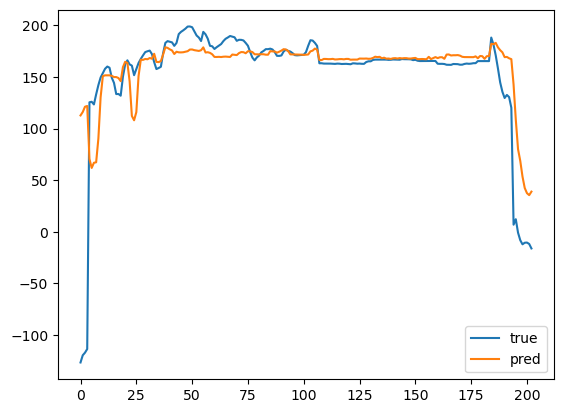

In [32]:
import matplotlib.pyplot as plt

plt.plot(y_test_rul, label="true")
plt.plot(y_pred, label="pred")
plt.legend()